# Welcome to Colab!

In [7]:
!pip install pyspark


In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

In [11]:
from google.colab import files
uploaded = files.upload()

Saving research-and-development-survey-2024.csv to research-and-development-survey-2024.csv


In [10]:
df = spark.read.csv("research-and-development-survey-2024.csv", header=True, inferSchema=True)
df.show(5)

+--------------------+--------------+--------------------+----+--------+------+--------------------+---------+-----------------------+
|            Variable|     Breakdown|  Breakdown_category|Year|RD_Value|Status|                Unit|Footnotes|Relative_Sampling_Error|
+--------------------+--------------+--------------------+----+--------+------+--------------------+---------+-----------------------+
|_01_Total_RD_Expe...|ANZSIC_1_Digit|A_Agriculture, Fo...|2016|      91|  NULL|NZ Dollars (milli...|       12|                   23.8|
|_01_Total_RD_Expe...|ANZSIC_1_Digit|A_Agriculture, Fo...|2018|      89|  NULL|NZ Dollars (milli...|       12|                   51.7|
|_01_Total_RD_Expe...|ANZSIC_1_Digit|A_Agriculture, Fo...|2019|     ...|  NULL|NZ Dollars (milli...|       12|                    ...|
|_01_Total_RD_Expe...|ANZSIC_1_Digit|A_Agriculture, Fo...|2020|      99|  NULL|NZ Dollars (milli...|       12|                   30.2|
|_01_Total_RD_Expe...|ANZSIC_1_Digit|A_Agriculture, Fo.

In [12]:
df.printSchema()      # structure
df.describe().show()  # summary stats
df.columns            # column names

root
 |-- Variable: string (nullable = true)
 |-- Breakdown: string (nullable = true)
 |-- Breakdown_category: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- RD_Value: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Unit: string (nullable = true)
 |-- Footnotes: string (nullable = true)
 |-- Relative_Sampling_Error: string (nullable = true)

+-------+--------------------+--------------+------------------+------------------+------------------+------+--------------------+--------------------+-----------------------+
|summary|            Variable|     Breakdown|Breakdown_category|              Year|          RD_Value|Status|                Unit|           Footnotes|Relative_Sampling_Error|
+-------+--------------------+--------------+------------------+------------------+------------------+------+--------------------+--------------------+-----------------------+
|  count|               48871|         48871|             48871|             48871|     

['Variable',
 'Breakdown',
 'Breakdown_category',
 'Year',
 'RD_Value',
 'Status',
 'Unit',
 'Footnotes',
 'Relative_Sampling_Error']

In [13]:
df = df.dropna()  # remove nulls

df = df.dropDuplicates()  # remove duplicates

In [14]:
from pyspark.sql.functions import col

In [15]:
df.select(df.columns).show(5)

+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+
|            Variable|         Breakdown|  Breakdown_category|Year|RD_Value|Status|                Unit|           Footnotes|Relative_Sampling_Error|
+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+
|_03_Current_and_C...|            Sector|  01_Business Sector|2023|     332|     R|NZ Dollars (milli...|     1 and 12 and 28|                   25.6|
|_12b_Purpose_of_r...|            Sector|  01_Business Sector|2022|     560|     R|NZ Dollars (milli...|1 and 12 and 15 a...|                    8.8|
|_13_Broad_purpose...|          Industry|03_Services Indus...|2023|     371|     R|NZ Dollars (milli...|12 and 15 and 19 ...|                   22.3|
|_22a_Personnel_by...|Published_Industry|12_Computer services|2023|    5000|     R| Number of employ

In [16]:
df.filter(col(df.columns[0]).isNotNull()).show()

+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+
|            Variable|         Breakdown|  Breakdown_category|Year|RD_Value|Status|                Unit|           Footnotes|Relative_Sampling_Error|
+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+
|_03_Current_and_C...|            Sector|  01_Business Sector|2023|     332|     R|NZ Dollars (milli...|     1 and 12 and 28|                   25.6|
|_12b_Purpose_of_r...|            Sector|  01_Business Sector|2022|     560|     R|NZ Dollars (milli...|1 and 12 and 15 a...|                    8.8|
|_13_Broad_purpose...|          Industry|03_Services Indus...|2023|     371|     R|NZ Dollars (milli...|12 and 15 and 19 ...|                   22.3|
|_22a_Personnel_by...|Published_Industry|12_Computer services|2023|    5000|     R| Number of employ

In [17]:
df = df.withColumn("New_Column", col(df.columns[1]))
df.show(5)

+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+------------------+
|            Variable|         Breakdown|  Breakdown_category|Year|RD_Value|Status|                Unit|           Footnotes|Relative_Sampling_Error|        New_Column|
+--------------------+------------------+--------------------+----+--------+------+--------------------+--------------------+-----------------------+------------------+
|_03_Current_and_C...|            Sector|  01_Business Sector|2023|     332|     R|NZ Dollars (milli...|     1 and 12 and 28|                   25.6|            Sector|
|_12b_Purpose_of_r...|            Sector|  01_Business Sector|2022|     560|     R|NZ Dollars (milli...|1 and 12 and 15 a...|                    8.8|            Sector|
|_13_Broad_purpose...|          Industry|03_Services Indus...|2023|     371|     R|NZ Dollars (milli...|12 and 15 and 19 ...|                   22.3|      

In [18]:
df.groupBy(df.columns[0]).count().show()

+--------------------+-----+
|            Variable|count|
+--------------------+-----+
|_35_Personnel_by_...|    6|
|_16_Type_of_resea...|   19|
|_02_Current_and_C...|   23|
|_32_Personnel_by_...|    5|
|_07_Source_of_Fun...|    5|
|_21_Personnel_by_...|   11|
|_13_Broad_purpose...|    7|
|_36_Personnel_by_...|    5|
|_13a_Purpose_of_r...|    8|
|_34_Personnel_by_...|    8|
|_12cii_Purpose_of...|    6|
|_28_Personnel_by_...|    8|
|_11aii_Purpose_of...|   12|
|_01_Total_RD_Expe...|   27|
|_18a_Personnel_by...|    7|
|_12b_Purpose_of_r...|   15|
|_92_Business_Sect...|    2|
|_23_Personnel_by_...|    8|
|_11a_Purpose_of_r...|   12|
|_15_Type_of_resea...|    8|
+--------------------+-----+
only showing top 20 rows


In [19]:
df.select(df.columns).describe().show()

+-------+--------------------+--------------+------------------+------------------+------------------+------+--------------------+--------------+-----------------------+--------------+
|summary|            Variable|     Breakdown|Breakdown_category|              Year|          RD_Value|Status|                Unit|     Footnotes|Relative_Sampling_Error|    New_Column|
+-------+--------------------+--------------+------------------+------------------+------------------+------+--------------------+--------------+-----------------------+--------------+
|  count|                 503|           503|               503|               503|               503|   503|                 503|           503|                    503|           503|
|   mean|                NULL|          NULL|              NULL|2022.4095427435389|1836.4784890656063|  NULL|                NULL|          12.0|     16.559318637274547|          NULL|
| stddev|                NULL|          NULL|              NULL|0.515949198

In [20]:
df.groupBy(df.columns[1]).count().orderBy("count", ascending=False).show()

+------------------+-----+
|         Breakdown|count|
+------------------+-----+
|Published_Industry|  192|
|          Industry|  122|
|            Sector|   67|
|    ANZSIC_1_Digit|   56|
|              Size|   33|
|             Total|   29|
|           Country|    4|
+------------------+-----+



In [21]:
df.orderBy(col(df.columns[0]).desc()).show(10)

+--------------------+------------------+--------------------+----+--------+------+--------------------+---------------+-----------------------+------------------+
|            Variable|         Breakdown|  Breakdown_category|Year|RD_Value|Status|                Unit|      Footnotes|Relative_Sampling_Error|        New_Column|
+--------------------+------------------+--------------------+----+--------+------+--------------------+---------------+-----------------------+------------------+
|_95_Total_RD_Expe...|           Country|         New Zealand|2022|    1.49|     R|   Percentage of GDP|      12 and 32|                     ..|           Country|
|_95_Total_RD_Expe...|           Country|         New Zealand|2020|    1.46|     R|   Percentage of GDP|      12 and 32|                     ..|           Country|
|_92_Business_Sect...|           Country|         New Zealand|2022|    0.89|     R|   Percentage of GDP|1 and 12 and 32|                     ..|           Country|
|_92_Business_Se

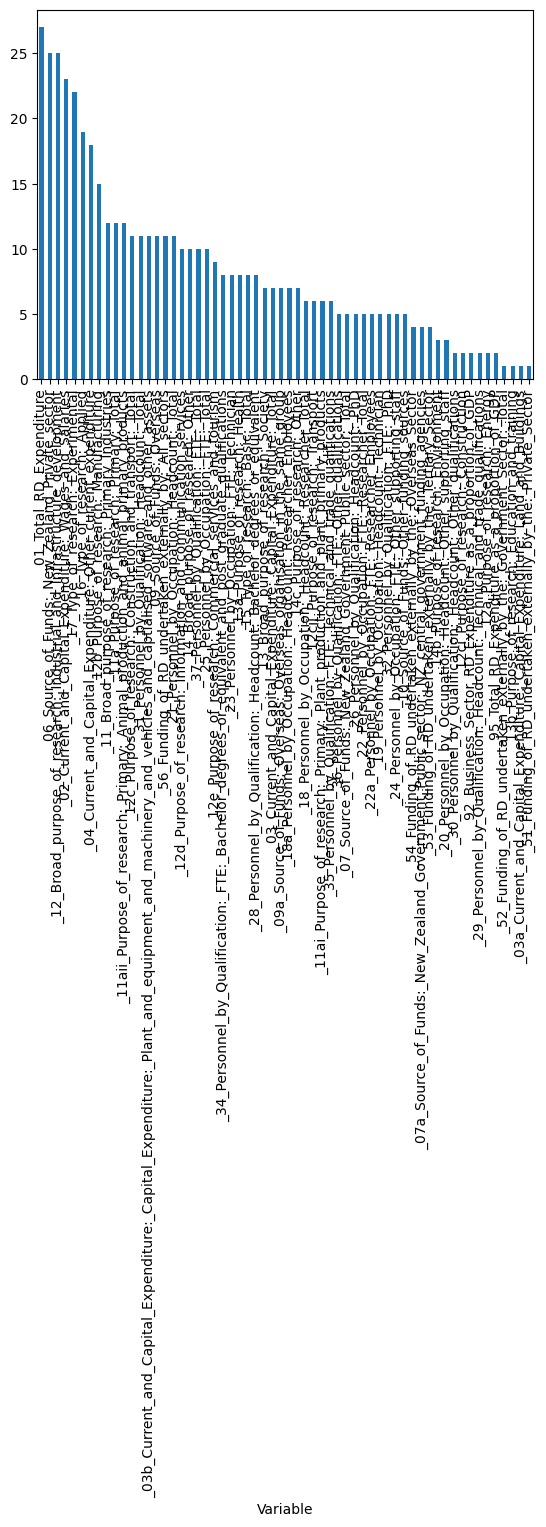

In [22]:
pdf = df.limit(1000).toPandas()

import matplotlib.pyplot as plt

pdf[df.columns[0]].value_counts().plot(kind='bar')
plt.show()

In [23]:
df.write.csv("processed_output.csv", header=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')